In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# load the clean ml-ready dataset
ml_data = pd.read_parquet("../data/ml_data.parquet")

# separate features and labels
FEATURES = ["mom_12_1", "mom_6_1", "mom_1m", "vol_1m", "vol_3m"]
TARGET   = "label"

print(f"loaded: {ml_data.shape}")
print(f"date range: {ml_data.index.get_level_values('Date').min()} "
      f"to {ml_data.index.get_level_values('Date').max()}")

loaded: (606490, 6)
date range: 2020-01-02 00:00:00 to 2024-11-27 00:00:00


In [2]:
# ── WALK-FORWARD CROSS VALIDATION ────────────────────────────────
# Get all unique month-end dates to use as rebalance points
dates = ml_data.index.get_level_values("Date").unique().sort_values()

# resample to month-end dates only
# we only retrain and rebalance once a month
monthly_dates = pd.Series(dates).groupby(
    pd.to_datetime(dates).to_period("M")
).last().values

print(f"total monthly periods: {len(monthly_dates)}")
print(f"first 5: {monthly_dates[:5]}")
print(f"last 5:  {monthly_dates[-5:]}")

# walk-forward parameters
TRAIN_MONTHS  = 24   # train on 2 years of data
EMBARGO_MONTHS = 1   # gap between train end and test start
# everything after train + embargo is the test month

print(f"\nwalk-forward setup:")
print(f"  train window : {TRAIN_MONTHS} months")
print(f"  embargo gap  : {EMBARGO_MONTHS} month")
print(f"  total folds  : {len(monthly_dates) - TRAIN_MONTHS - EMBARGO_MONTHS}")

total monthly periods: 59
first 5: ['2020-01-31T00:00:00.000000000' '2020-02-28T00:00:00.000000000'
 '2020-03-31T00:00:00.000000000' '2020-04-30T00:00:00.000000000'
 '2020-05-29T00:00:00.000000000']
last 5:  ['2024-07-31T00:00:00.000000000' '2024-08-30T00:00:00.000000000'
 '2024-09-30T00:00:00.000000000' '2024-10-31T00:00:00.000000000'
 '2024-11-27T00:00:00.000000000']

walk-forward setup:
  train window : 24 months
  embargo gap  : 1 month
  total folds  : 34


In [3]:
# ── WALK-FORWARD TRAINING LOOP ────────────────────────────────────
results = []  # store predictions for every test month

for i in range(TRAIN_MONTHS + EMBARGO_MONTHS, len(monthly_dates)):
    
    # define train and test periods
    train_end   = monthly_dates[i - EMBARGO_MONTHS - 1]
    test_month  = monthly_dates[i]
    train_start = monthly_dates[max(0, i - TRAIN_MONTHS - EMBARGO_MONTHS)]
    
    # slice data
    train_data = ml_data.loc[
        (ml_data.index.get_level_values("Date") >= train_start) &
        (ml_data.index.get_level_values("Date") <= train_end)
    ]
    test_data = ml_data.loc[
        ml_data.index.get_level_values("Date") == test_month
    ]
    
    # skip if not enough data
    if len(train_data) < 1000 or len(test_data) < 10:
        continue
    
    X_train = train_data[FEATURES]
    y_train = train_data[TARGET]
    X_test  = test_data[FEATURES]
    y_test  = test_data[TARGET]
    
    # train LightGBM
    model = lgb.LGBMRegressor(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        random_state     = 42,
        verbose          = -1
    )
    model.fit(X_train, y_train)
    
    # predict on test month
    preds = model.predict(X_test)
    
    # calculate IC for this month
    ic, _ = spearmanr(preds, y_test)
    
    # store results
    results.append({
        "date"  : test_month,
        "ic"    : ic,
        "preds" : pd.Series(preds, index=y_test.index),
        "actual": y_test
    })
    
    print(f"fold {i - TRAIN_MONTHS - EMBARGO_MONTHS + 1:02d} | "
          f"test: {str(test_month)[:7]} | "
          f"train size: {len(train_data):6d} | "
          f"IC: {ic:.4f}")

print(f"\ndone — {len(results)} folds completed")

fold 01 | test: 2022-02 | train size: 235234 | IC: -0.1590
fold 02 | test: 2022-03 | train size: 235952 | IC: -0.1707
fold 03 | test: 2022-04 | train size: 234724 | IC: 0.0249
fold 04 | test: 2022-05 | train size: 235916 | IC: -0.2934
fold 05 | test: 2022-06 | train size: 236125 | IC: 0.0308
fold 06 | test: 2022-07 | train size: 235839 | IC: -0.1490
fold 07 | test: 2022-08 | train size: 235544 | IC: -0.1908
fold 08 | test: 2022-09 | train size: 235241 | IC: 0.0028
fold 09 | test: 2022-10 | train size: 236431 | IC: 0.1641
fold 10 | test: 2022-11 | train size: 236135 | IC: -0.1241
fold 11 | test: 2022-12 | train size: 236809 | IC: 0.2628
fold 12 | test: 2023-01 | train size: 236513 | IC: -0.0476
fold 13 | test: 2023-02 | train size: 237672 | IC: 0.0952
fold 14 | test: 2023-03 | train size: 238345 | IC: -0.0048
fold 15 | test: 2023-04 | train size: 236579 | IC: 0.0019
fold 16 | test: 2023-05 | train size: 237737 | IC: -0.1829
fold 17 | test: 2023-06 | train size: 237402 | IC: -0.0552
fold

In [4]:
# ── IC SUMMARY STATISTICS ─────────────────────────────────────────
ic_series = pd.Series(
    [r["ic"] for r in results],
    index=[r["date"] for r in results]
)

ic_mean   = ic_series.mean()
ic_std    = ic_series.std()
ic_ir     = ic_mean / ic_std          # information ratio
ic_positive = (ic_series > 0).mean()  # % of months with positive IC

print("── IC Summary ──────────────────────────")
print(f"  Mean IC      : {ic_mean:.4f}")
print(f"  IC Std       : {ic_std:.4f}")
print(f"  IC IR        : {ic_ir:.4f}")
print(f"  Positive IC  : {ic_positive:.1%} of months")
print(f"  Best month   : {ic_series.idxmax().strftime('%Y-%m')} ({ic_series.max():.4f})")
print(f"  Worst month  : {ic_series.idxmin().strftime('%Y-%m')} ({ic_series.min():.4f})")
print("────────────────────────────────────────")

── IC Summary ──────────────────────────
  Mean IC      : -0.0130
  IC Std       : 0.1334
  IC IR        : -0.0974
  Positive IC  : 47.1% of months
  Best month   : 2022-12 (0.2628)
  Worst month  : 2022-05 (-0.2934)
────────────────────────────────────────


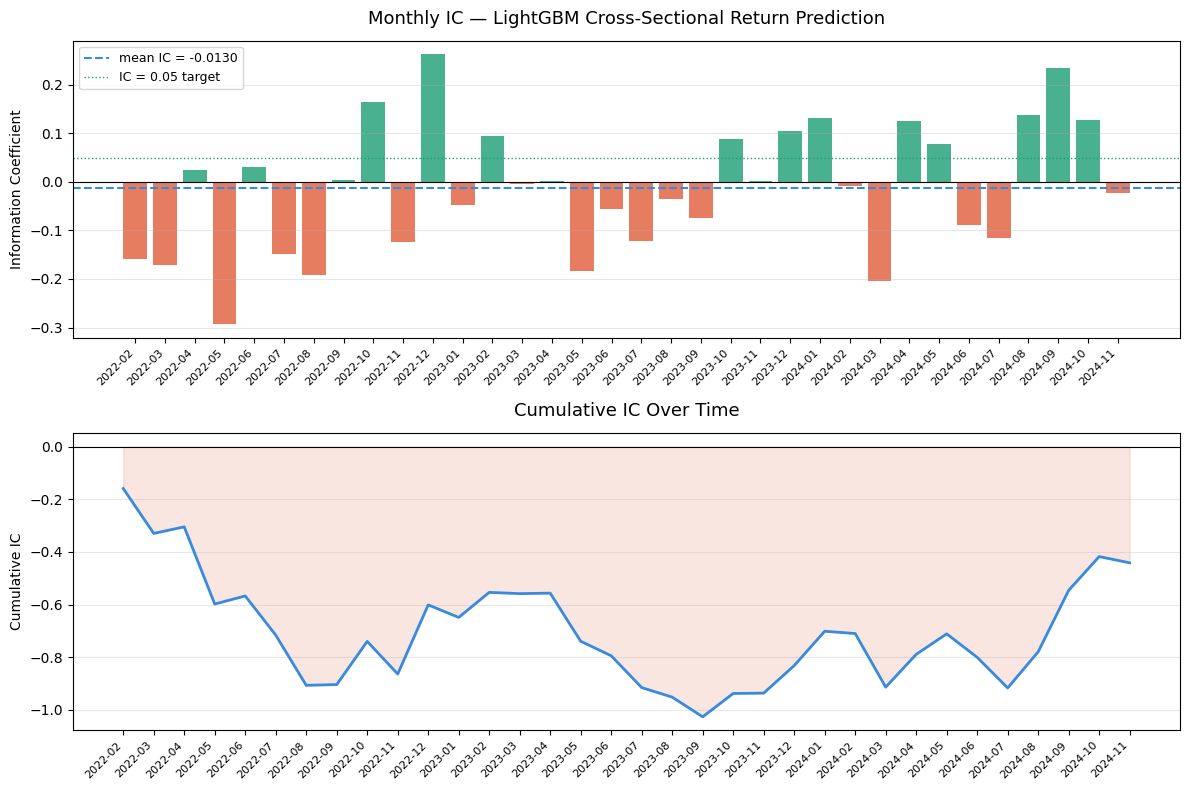

chart saved


In [5]:
# ── IC OVER TIME CHART ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# top chart - IC per month as bars
ax1 = axes[0]
colors = ["#1D9E75" if x > 0 else "#E05C3A" for x in ic_series.values]
ax1.bar(range(len(ic_series)), ic_series.values, color=colors, alpha=0.8)
ax1.axhline(0,            color="black",  linewidth=0.8, linestyle="-")
ax1.axhline(ic_mean,      color="#378ADD", linewidth=1.5, linestyle="--", 
            label=f"mean IC = {ic_mean:.4f}")
ax1.axhline(0.05,         color="#1D9E75", linewidth=1,   linestyle=":", 
            label="IC = 0.05 target")
ax1.set_xticks(range(len(ic_series)))
ax1.set_xticklabels(
    [str(d)[:7] for d in ic_series.index],
    rotation=45, ha="right", fontsize=8
)
ax1.set_title("Monthly IC — LightGBM Cross-Sectional Return Prediction", 
              fontsize=13, pad=12)
ax1.set_ylabel("Information Coefficient")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# bottom chart - cumulative IC
ax2 = axes[1]
cumulative_ic = ic_series.cumsum()
ax2.plot(range(len(cumulative_ic)), cumulative_ic.values, 
         color="#378ADD", linewidth=2)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.fill_between(range(len(cumulative_ic)), cumulative_ic.values, 0,
                 where=cumulative_ic.values >= 0,
                 alpha=0.15, color="#1D9E75")
ax2.fill_between(range(len(cumulative_ic)), cumulative_ic.values, 0,
                 where=cumulative_ic.values < 0,
                 alpha=0.15, color="#E05C3A")
ax2.set_xticks(range(len(ic_series)))
ax2.set_xticklabels(
    [str(d)[:7] for d in ic_series.index],
    rotation=45, ha="right", fontsize=8
)
ax2.set_title("Cumulative IC Over Time", fontsize=13, pad=12)
ax2.set_ylabel("Cumulative IC")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/ic_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("chart saved")

In [6]:
# ── RETRAIN EXCLUDING PRE-2021 DATA ───────────────────────────────
# 2020 COVID crash creates unusual patterns that hurt generalisation
# Start from 2021 for cleaner training signal

ml_data_v2 = ml_data.loc[
    ml_data.index.get_level_values("Date") >= "2021-01-01"
]

dates_v2 = ml_data_v2.index.get_level_values("Date").unique().sort_values()
monthly_dates_v2 = pd.Series(dates_v2).groupby(
    pd.to_datetime(dates_v2).to_period("M")
).last().values

print(f"trimmed dataset: {ml_data_v2.shape}")
print(f"monthly periods: {len(monthly_dates_v2)}")
print(f"total folds available: {len(monthly_dates_v2) - TRAIN_MONTHS - EMBARGO_MONTHS}")

trimmed dataset: (484412, 6)
monthly periods: 47
total folds available: 22


In [7]:
# ── RETRAINED WALK-FORWARD LOOP (v2) ─────────────────────────────
results_v2 = []

for i in range(TRAIN_MONTHS + EMBARGO_MONTHS, len(monthly_dates_v2)):
    
    train_end   = monthly_dates_v2[i - EMBARGO_MONTHS - 1]
    test_month  = monthly_dates_v2[i]
    train_start = monthly_dates_v2[max(0, i - TRAIN_MONTHS - EMBARGO_MONTHS)]
    
    train_data = ml_data_v2.loc[
        (ml_data_v2.index.get_level_values("Date") >= train_start) &
        (ml_data_v2.index.get_level_values("Date") <= train_end)
    ]
    test_data = ml_data_v2.loc[
        ml_data_v2.index.get_level_values("Date") == test_month
    ]
    
    if len(train_data) < 1000 or len(test_data) < 10:
        continue
    
    X_train = train_data[FEATURES]
    y_train = train_data[TARGET]
    X_test  = test_data[FEATURES]
    y_test  = test_data[TARGET]
    
    model = lgb.LGBMRegressor(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        random_state     = 42,
        verbose          = -1
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    ic, _ = spearmanr(preds, y_test)
    
    results_v2.append({
        "date"  : test_month,
        "ic"    : ic,
        "preds" : pd.Series(preds, index=y_test.index),
        "actual": y_test
    })
    
    print(f"fold {i - TRAIN_MONTHS - EMBARGO_MONTHS + 1:02d} | "
          f"test: {str(test_month)[:7]} | "
          f"train size: {len(train_data):6d} | "
          f"IC: {ic:.4f}")

print(f"\ndone — {len(results_v2)} folds completed")

fold 01 | test: 2023-02 | train size: 237672 | IC: 0.0952
fold 02 | test: 2023-03 | train size: 238345 | IC: -0.0048
fold 03 | test: 2023-04 | train size: 236579 | IC: 0.0019
fold 04 | test: 2023-05 | train size: 237737 | IC: -0.1829
fold 05 | test: 2023-06 | train size: 237402 | IC: -0.0552
fold 06 | test: 2023-07 | train size: 237578 | IC: -0.1209
fold 07 | test: 2023-08 | train size: 237746 | IC: -0.0363
fold 08 | test: 2023-09 | train size: 236932 | IC: -0.0748
fold 09 | test: 2023-10 | train size: 238090 | IC: 0.0888
fold 10 | test: 2023-11 | train size: 237742 | IC: 0.0013
fold 11 | test: 2023-12 | train size: 238384 | IC: 0.1047
fold 12 | test: 2024-01 | train size: 238014 | IC: 0.1305
fold 13 | test: 2024-02 | train size: 238123 | IC: -0.0086
fold 14 | test: 2024-03 | train size: 239217 | IC: -0.2038
fold 15 | test: 2024-04 | train size: 237844 | IC: 0.1246
fold 16 | test: 2024-05 | train size: 237921 | IC: 0.0781
fold 17 | test: 2024-06 | train size: 238480 | IC: -0.0894
fold 

In [8]:
ic_series_v2 = pd.Series(
    [r["ic"] for r in results_v2],
    index=[r["date"] for r in results_v2]
)

ic_mean_v2     = ic_series_v2.mean()
ic_std_v2      = ic_series_v2.std()
ic_ir_v2       = ic_mean_v2 / ic_std_v2
ic_positive_v2 = (ic_series_v2 > 0).mean()

print("── IC Summary v2 ───────────────────────")
print(f"  Mean IC      : {ic_mean_v2:.4f}")
print(f"  IC Std       : {ic_std_v2:.4f}")
print(f"  IC IR        : {ic_ir_v2:.4f}")
print(f"  Positive IC  : {ic_positive_v2:.1%} of months")
print(f"  Best month   : {ic_series_v2.idxmax().strftime('%Y-%m')} ({ic_series_v2.max():.4f})")
print(f"  Worst month  : {ic_series_v2.idxmin().strftime('%Y-%m')} ({ic_series_v2.min():.4f})")
print("────────────────────────────────────────")

# compare to v1
print(f"\n── vs v1 ───────────────────────────────")
print(f"  Mean IC v1   : {ic_mean:.4f}  →  v2: {ic_mean_v2:.4f}")
print(f"  IC IR  v1    : {ic_ir:.4f}  →  v2: {ic_ir_v2:.4f}")
print(f"  Positive  v1 : {ic_positive:.1%}  →  v2: {ic_positive_v2:.1%}")
print("────────────────────────────────────────")

── IC Summary v2 ───────────────────────
  Mean IC      : 0.0094
  IC Std       : 0.1147
  IC IR        : 0.0822
  Positive IC  : 50.0% of months
  Best month   : 2024-09 (0.2338)
  Worst month  : 2024-03 (-0.2038)
────────────────────────────────────────

── vs v1 ───────────────────────────────
  Mean IC v1   : -0.0130  →  v2: 0.0094
  IC IR  v1    : -0.0974  →  v2: 0.0822
  Positive  v1 : 47.1%  →  v2: 50.0%
────────────────────────────────────────


In [9]:
# save IC series for later use in charts and HMM overlay
ic_series_v2.to_frame(name="ic").to_parquet("../data/ic_series.parquet")

# save all predictions for quintile portfolio construction
all_preds  = pd.concat([r["preds"]  for r in results_v2])
all_actual = pd.concat([r["actual"] for r in results_v2])

pred_df = pd.DataFrame({
    "pred"  : all_preds,
    "actual": all_actual
})
pred_df.to_parquet("../data/predictions.parquet")

print(f"saved ic_series: {len(ic_series_v2)} months")
print(f"saved predictions: {pred_df.shape}")
print(pred_df.head())

saved ic_series: 22 months
saved predictions: (10911, 2)
                       pred    actual
Date       Ticker                    
2023-02-28 A      -0.005345 -0.041797
           AAPL    0.002121  0.106030
           ABBV    0.003973  0.042039
           ABNB    0.013715 -0.020942
           ABT     0.004078 -0.015078


In [10]:
import os

data_files = os.listdir("../data")
for f in sorted(data_files):
    size = os.path.getsize(f"../data/{f}")
    print(f"  {f:<30} {size/1024/1024:.1f} MB")

  ic_over_time.png               0.1 MB
  ic_series.parquet              0.0 MB
  ic_series_v3.parquet           0.0 MB
  ml_data.parquet                9.7 MB
  ml_data_v3.parquet             12.6 MB
  predictions.parquet            0.2 MB
  predictions_v3.parquet         0.2 MB
  quintile_fan_chart.png         0.2 MB
  sp500_raw.parquet              29.8 MB


In [11]:
# ── RETRAIN WITH 9 FEATURES ───────────────────────────────────────
ml_data_v3 = pd.read_parquet("../data/ml_data_v3.parquet")

FEATURES_V3 = ["mom_12_1", "mom_6_1", "mom_1m", "vol_1m", 
               "vol_3m", "price_to_high", "reversal_5d", "vol_ratio"]

# trim to 2021 same as v2
ml_data_v3 = ml_data_v3.loc[
    ml_data_v3.index.get_level_values("Date") >= "2021-01-01"
]

dates_v3 = ml_data_v3.index.get_level_values("Date").unique().sort_values()
monthly_dates_v3 = pd.Series(dates_v3).groupby(
    pd.to_datetime(dates_v3).to_period("M")
).last().values

results_v3 = []

for i in range(TRAIN_MONTHS + EMBARGO_MONTHS, len(monthly_dates_v3)):

    train_end   = monthly_dates_v3[i - EMBARGO_MONTHS - 1]
    test_month  = monthly_dates_v3[i]
    train_start = monthly_dates_v3[max(0, i - TRAIN_MONTHS - EMBARGO_MONTHS)]

    train_data = ml_data_v3.loc[
        (ml_data_v3.index.get_level_values("Date") >= train_start) &
        (ml_data_v3.index.get_level_values("Date") <= train_end)
    ]
    test_data = ml_data_v3.loc[
        ml_data_v3.index.get_level_values("Date") == test_month
    ]

    if len(train_data) < 1000 or len(test_data) < 10:
        continue

    X_train = train_data[FEATURES_V3]
    y_train = train_data[TARGET]
    X_test  = test_data[FEATURES_V3]
    y_test  = test_data[TARGET]

    model = lgb.LGBMRegressor(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        random_state     = 42,
        verbose          = -1
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ic, _ = spearmanr(preds, y_test)

    results_v3.append({
        "date"  : test_month,
        "ic"    : ic,
        "preds" : pd.Series(preds, index=y_test.index),
        "actual": y_test
    })

    print(f"fold {i - TRAIN_MONTHS - EMBARGO_MONTHS + 1:02d} | "
          f"test: {str(test_month)[:7]} | "
          f"IC: {ic:.4f}")

print(f"\ndone — {len(results_v3)} folds completed")

fold 01 | test: 2023-02 | IC: 0.0354
fold 02 | test: 2023-03 | IC: 0.0333
fold 03 | test: 2023-04 | IC: -0.0387
fold 04 | test: 2023-05 | IC: -0.1826
fold 05 | test: 2023-06 | IC: -0.0164
fold 06 | test: 2023-07 | IC: -0.0538
fold 07 | test: 2023-08 | IC: -0.0594
fold 08 | test: 2023-09 | IC: -0.0343
fold 09 | test: 2023-10 | IC: 0.0538
fold 10 | test: 2023-11 | IC: -0.0532
fold 11 | test: 2023-12 | IC: 0.1772
fold 12 | test: 2024-01 | IC: 0.1856
fold 13 | test: 2024-02 | IC: 0.0033
fold 14 | test: 2024-03 | IC: -0.1348
fold 15 | test: 2024-04 | IC: 0.1316
fold 16 | test: 2024-05 | IC: 0.0683
fold 17 | test: 2024-06 | IC: -0.0820
fold 18 | test: 2024-07 | IC: -0.1265
fold 19 | test: 2024-08 | IC: 0.0970
fold 20 | test: 2024-09 | IC: 0.2157
fold 21 | test: 2024-10 | IC: 0.0935
fold 22 | test: 2024-11 | IC: -0.0220

done — 22 folds completed


In [12]:
ic_series_v3 = pd.Series(
    [r["ic"] for r in results_v3],
    index=[r["date"] for r in results_v3]
)

ic_mean_v3     = ic_series_v3.mean()
ic_std_v3      = ic_series_v3.std()
ic_ir_v3       = ic_mean_v3 / ic_std_v3
ic_positive_v3 = (ic_series_v3 > 0).mean()

print("── IC Summary v3 (8 features) ──────────")
print(f"  Mean IC      : {ic_mean_v3:.4f}")
print(f"  IC Std       : {ic_std_v3:.4f}")
print(f"  IC IR        : {ic_ir_v3:.4f}")
print(f"  Positive IC  : {ic_positive_v3:.1%} of months")
print("────────────────────────────────────────")
print(f"\n── Progression ─────────────────────────")
print(f"  v1 (5 feat, full) : IC {ic_mean:.4f}  IR {ic_ir:.4f}")
print(f"  v2 (5 feat, 2021) : IC {ic_mean_v2:.4f}  IR {ic_ir_v2:.4f}")
print(f"  v3 (8 feat, 2021) : IC {ic_mean_v3:.4f}  IR {ic_ir_v3:.4f}")
print("────────────────────────────────────────")

── IC Summary v3 (8 features) ──────────
  Mean IC      : 0.0132
  IC Std       : 0.1071
  IC IR        : 0.1235
  Positive IC  : 50.0% of months
────────────────────────────────────────

── Progression ─────────────────────────
  v1 (5 feat, full) : IC -0.0130  IR -0.0974
  v2 (5 feat, 2021) : IC 0.0094  IR 0.0822
  v3 (8 feat, 2021) : IC 0.0132  IR 0.1235
────────────────────────────────────────


In [13]:
# save v3 results
ic_series_v3.to_frame(name="ic").to_parquet("../data/ic_series_v3.parquet")

all_preds_v3  = pd.concat([r["preds"]  for r in results_v3])
all_actual_v3 = pd.concat([r["actual"] for r in results_v3])

pred_df_v3 = pd.DataFrame({
    "pred"  : all_preds_v3,
    "actual": all_actual_v3
})
pred_df_v3.to_parquet("../data/predictions_v3.parquet")

print(f"saved ic_series_v3  : {len(ic_series_v3)} months")
print(f"saved predictions_v3: {pred_df_v3.shape}")

saved ic_series_v3  : 22 months
saved predictions_v3: (10911, 2)
